# Companion code for learning and validation curves

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, learning_curve, train_test_split, validation_curve
from torch.utils.data import DataLoader, TensorDataset

## Learning curve on a baseline classifier

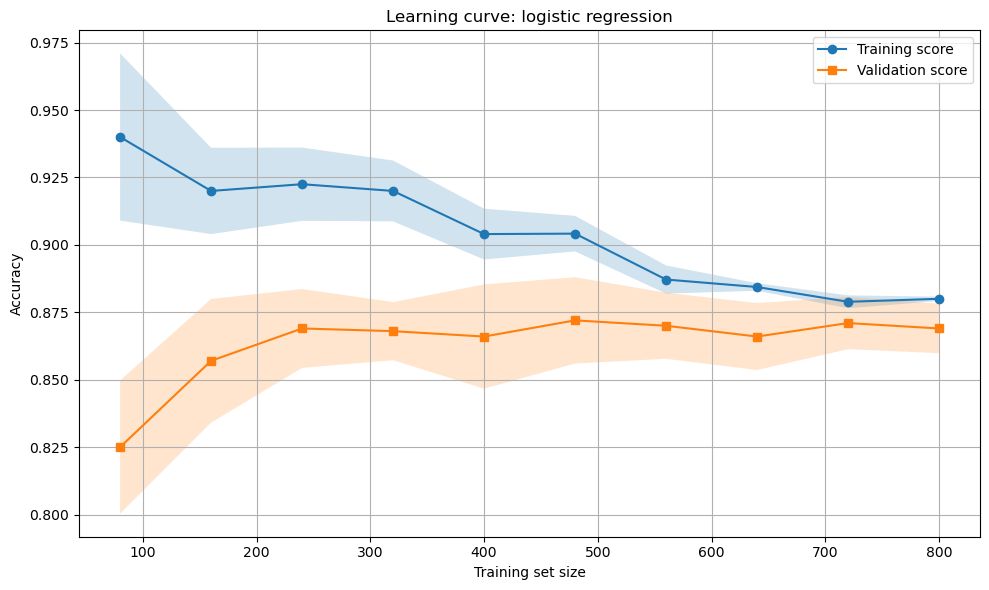

In [2]:
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000),
    X,
    y,
    cv=cv,
    train_sizes=train_sizes,
    scoring="accuracy",
    n_jobs=-1,
)


def plot_score_curve(x_values, train_scores, val_scores, title, xlabel, log_x=False):
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(10, 6))
    plot_fn = plt.semilogx if log_x else plt.plot
    plot_fn(x_values, train_mean, marker="o", label="Training score")
    plot_fn(x_values, val_mean, marker="s", label="Validation score")
    plt.fill_between(x_values, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(x_values, val_mean - val_std, val_mean + val_std, alpha=0.2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_score_curve(
    train_sizes_abs,
    train_scores,
    val_scores,
    "Learning curve: logistic regression",
    "Training set size",
)

## Validation curve on logistic regression

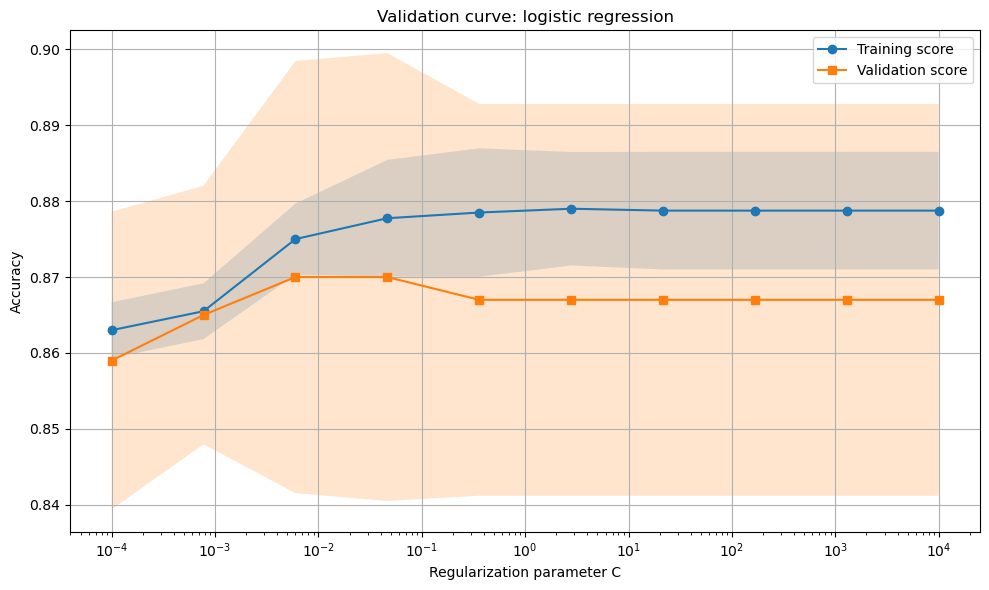

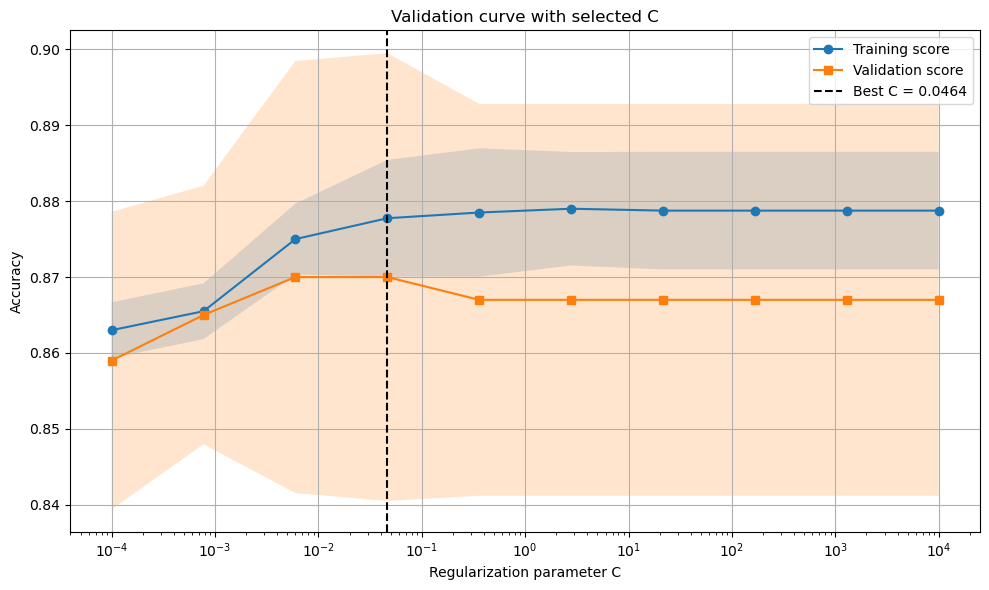

In [3]:
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
param_range = np.logspace(-4, 4, 10)

train_scores, val_scores = validation_curve(
    LogisticRegression(max_iter=1000, solver="liblinear"),
    X,
    y,
    param_name="C",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

best_index = val_scores.mean(axis=1).argmax()
best_C = param_range[best_index]

plot_score_curve(
    param_range,
    train_scores,
    val_scores,
    "Validation curve: logistic regression",
    "Regularization parameter C",
    log_x=True,
)

plt.figure(figsize=(10, 6))
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)
plt.semilogx(param_range, train_mean, marker="o", label="Training score")
plt.semilogx(param_range, val_mean, marker="s", label="Validation score")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.axvline(best_C, color="black", linestyle="--", label=f"Best C = {best_C:.4f}")
plt.title("Validation curve with selected C")
plt.xlabel("Regularization parameter C")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## High-bias and high-variance learning curves

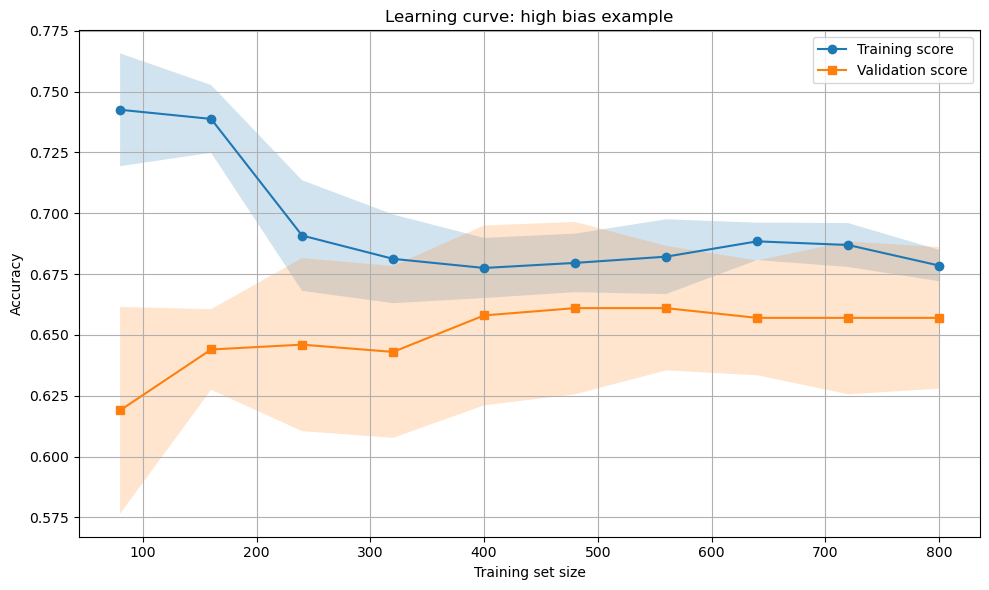

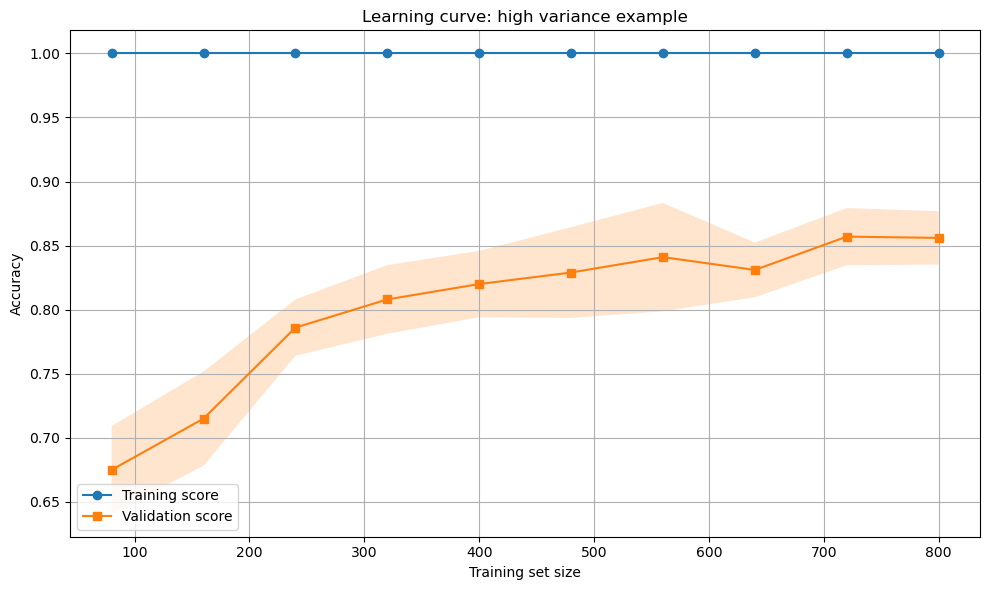

In [4]:
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=2,
    class_sep=0.5,
    random_state=42,
)

hard_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bias_sizes, bias_train_scores, bias_val_scores = learning_curve(
    LogisticRegression(max_iter=1000, penalty="l2", C=0.01, solver="liblinear"),
    X,
    y,
    train_sizes=train_sizes,
    cv=hard_cv,
    scoring="accuracy",
    n_jobs=-1,
)

plot_score_curve(
    bias_sizes,
    bias_train_scores,
    bias_val_scores,
    "Learning curve: high bias example",
    "Training set size",
)

variance_sizes, variance_train_scores, variance_val_scores = learning_curve(
    RandomForestClassifier(max_depth=None, n_estimators=300, random_state=42),
    X,
    y,
    train_sizes=train_sizes,
    cv=hard_cv,
    scoring="accuracy",
    n_jobs=-1,
)

plot_score_curve(
    variance_sizes,
    variance_train_scores,
    variance_val_scores,
    "Learning curve: high variance example",
    "Training set size",
)

## Loss curve and error analysis

/Users/ebezerra/miniconda3/envs/cic1205/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


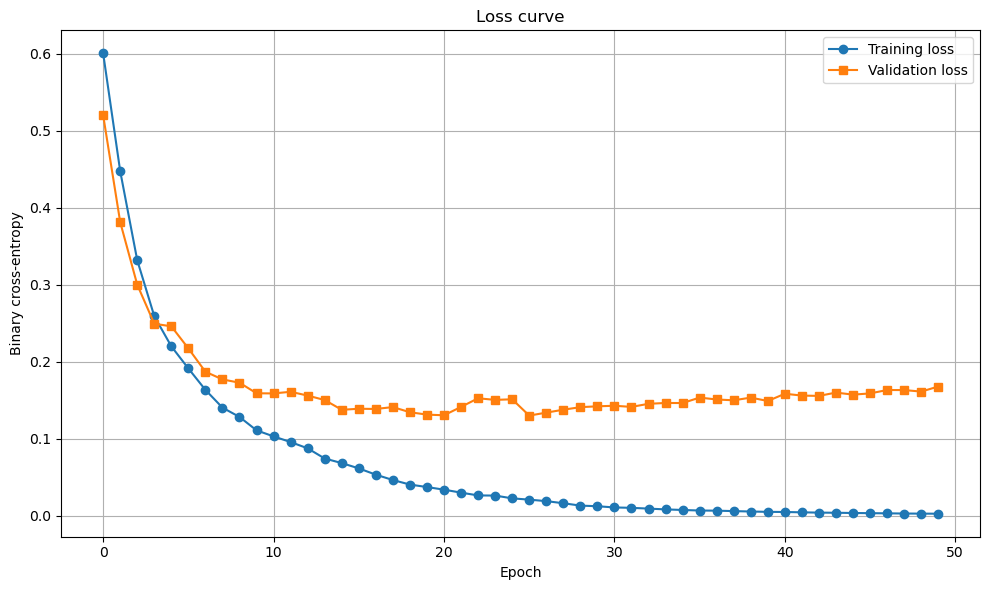

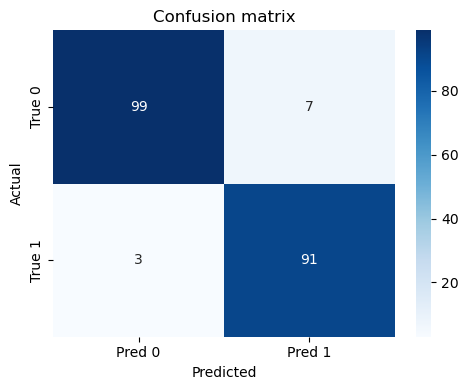

              precision    recall  f1-score   support

     Class 0       0.97      0.93      0.95       106
     Class 1       0.93      0.97      0.95        94

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200

Misclassified examples: 10


In [5]:
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    random_state=42,
)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)


class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)


model = SimpleNN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []
for _ in range(50):
    model.train()
    running_train_loss = 0.0
    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * xb.size(0)
    train_losses.append(running_train_loss / len(train_loader.dataset))

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            running_val_loss += loss.item() * xb.size(0)
    val_losses.append(running_val_loss / len(val_loader.dataset))

plt.figure(figsize=(10, 6))
plt.plot(train_losses, marker="o", label="Training loss")
plt.plot(val_losses, marker="s", label="Validation loss")
plt.title("Loss curve")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    val_probs = model(X_val_tensor).squeeze().numpy()
val_preds = (val_probs > 0.5).astype(int)

cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"],
)
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_val, val_preds, target_names=["Class 0", "Class 1"]))
misclassified = np.where(val_preds != y_val)[0]
print(f"Misclassified examples: {len(misclassified)}")

## Visualizing misclassified examples

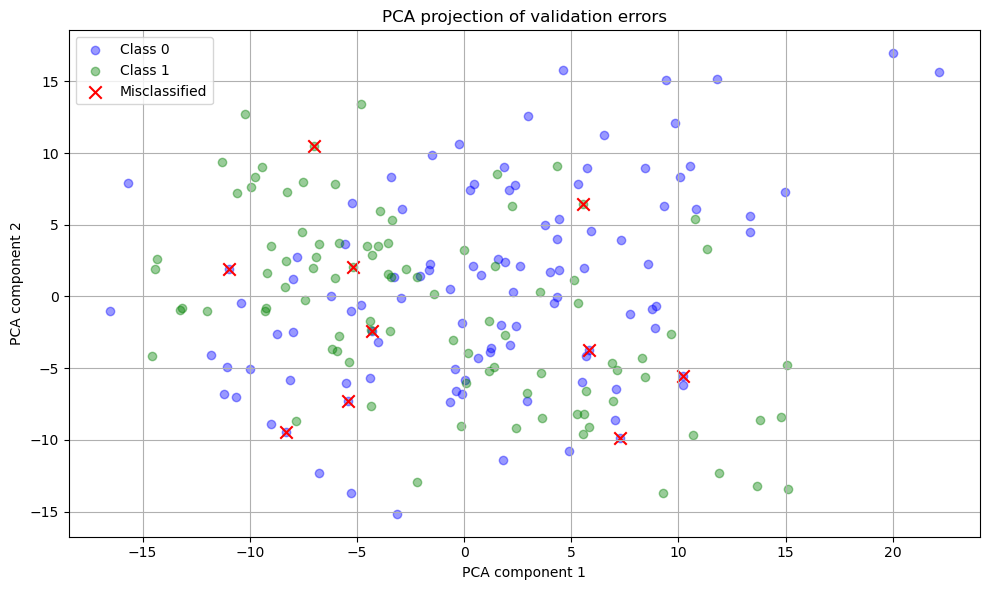

In [6]:
X_val_2d = PCA(n_components=2).fit_transform(X_val)

plt.figure(figsize=(10, 6))
plt.scatter(X_val_2d[y_val == 0, 0], X_val_2d[y_val == 0, 1], c="blue", alpha=0.4, label="Class 0")
plt.scatter(X_val_2d[y_val == 1, 0], X_val_2d[y_val == 1, 1], c="green", alpha=0.4, label="Class 1")
plt.scatter(
    X_val_2d[misclassified, 0],
    X_val_2d[misclassified, 1],
    c="red",
    marker="x",
    s=80,
    label="Misclassified",
)
plt.title("PCA projection of validation errors")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Flagging likely mislabeled examples

In [7]:
def flag_mislabeled_examples(model, X_val, y_val, threshold=0.9):
    model.eval()
    with torch.no_grad():
        probs = model(X_val).squeeze().numpy()
    preds = (probs > 0.5).astype(int)
    disagreement = preds != y_val

    high_confidence_wrong = (
        ((probs >= threshold) & (preds == 1) & disagreement)
        | ((probs <= 1 - threshold) & (preds == 0) & disagreement)
    )
    flagged_indices = np.where(high_confidence_wrong)[0]
    return flagged_indices, probs, preds


flagged, probs, preds = flag_mislabeled_examples(model, X_val_tensor, y_val)
print(f"Flagged examples: {len(flagged)}")

for idx in flagged[:5]:
    print(
        f"Index: {idx} | True label: {int(y_val[idx])} | "
        f"Predicted: {preds[idx]} | Confidence: {probs[idx]:.4f}"
    )

Flagged examples: 7
Index: 11 | True label: 1 | Predicted: 0 | Confidence: 0.0013
Index: 45 | True label: 1 | Predicted: 0 | Confidence: 0.0957
Index: 75 | True label: 1 | Predicted: 0 | Confidence: 0.0138
Index: 84 | True label: 0 | Predicted: 1 | Confidence: 0.9165
Index: 125 | True label: 0 | Predicted: 1 | Confidence: 0.9157
